## 1. Imports and Setup
We begin by importing all required Python libraries for data loading, preprocessing,
visualization, and model training. We also set a fixed random seed for reproducibility.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, fbeta_score, confusion_matrix

rng_seed = 42

## 2. Load Data and Cleaning
We load the semiconductor dataset, remove irrelevant data columns, and 
one-hot encode categorical features. This prepares the data for model training.

In [21]:
raw_data = pd.read_csv('semiconductor_quality_control.csv')
print("Raw Data Shape:", raw_data.shape)

features = raw_data.columns.drop(['Defect'])
clean_data = raw_data.copy()

cols_to_drop = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Join_Status']
clean_data = clean_data.drop(columns = cols_to_drop)

print("Clean Data Shape:", clean_data.shape)
clean_data = pd.get_dummies(clean_data, columns=['Tool_Type'], drop_first=False)

clean_features = clean_data.columns.drop(['Defect'])


N0 = clean_data['Defect'].value_counts()[0]
N1 = clean_data['Defect'].value_counts()[1]
print(f"Number of Non-Defective Samples: {N0}")
print(f"Number of Defective Samples: {N1}")

Raw Data Shape: (4219, 16)
Clean Data Shape: (4219, 12)
Number of Non-Defective Samples: 3602
Number of Defective Samples: 617


## 3. Train/Test Split

In [22]:
Xdata = clean_data[clean_features]
ydata = clean_data['Defect']
X_train, X_test, y_train, y_test = train_test_split(Xdata, ydata, test_size=0.2, random_state=rng_seed, stratify=ydata)

print("Train class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Train class distribution:
Defect
0    2881
1     494
Name: count, dtype: int64

Test class distribution:
Defect
0    721
1    123
Name: count, dtype: int64


## 4. Handling Class Imbalance via Majority-Class Chunking
The dataset is extremely imbalanced. Instead of oversampling or SMOTE, we split the majority class 
into multiple chunks and train *one AdaBoost model per chunk*, each with all minority samples included.

This creates several balanced models, whose predictions we later average.
This provides a stable estimate of minority-class probability.

In [23]:
# Splitting majority class manually
train_df = pd.concat([X_train.reset_index(drop=True),
                      y_train.reset_index(drop=True)], axis=1)

majority_df = train_df[train_df["Defect"] == 0].reset_index(drop=True)
minority_df = train_df[train_df["Defect"] == 1].reset_index(drop=True)

print("Majority size:", len(majority_df))
print("Minority size:", len(minority_df))

chunk_sizes = [494, 494, 494, 494, 494, 411]   # manually chosen
majority_chunks = []
start = 0
for size in chunk_sizes:
    end = start + size
    majority_chunks.append(majority_df.iloc[start:end].copy())
    start = end

print("\nMajority chunks created:")
for i, ch in enumerate(majority_chunks):
    print(f"Chunk {i+1} size = {len(ch)}")

Majority size: 2881
Minority size: 494

Majority chunks created:
Chunk 1 size = 494
Chunk 2 size = 494
Chunk 3 size = 494
Chunk 4 size = 494
Chunk 5 size = 494
Chunk 6 size = 411


## 5. AdaBoost Ensemble Evaluation
For each learning rate and each number of estimators, we:
1. Train one AdaBoost model per majority chunk (balanced datasets).
2. Average their predicted probabilities.
3. Evaluate the classification using Recall and F2-score (β = 2 favors Recall).

LR=0.1, n=10 | Recall=0.2439, F2=0.1935
LR=0.1, n=25 | Recall=0.4390, F2=0.2935
LR=0.1, n=50 | Recall=0.5935, F2=0.3506
LR=0.1, n=100 | Recall=0.6098, F2=0.3521
LR=0.1, n=200 | Recall=0.5854, F2=0.3399
LR=0.1, n=400 | Recall=0.5691, F2=0.3428
LR=0.3, n=10 | Recall=0.4309, F2=0.2896
LR=0.3, n=25 | Recall=0.6016, F2=0.3487
LR=0.3, n=50 | Recall=0.4715, F2=0.2941
LR=0.3, n=100 | Recall=0.5772, F2=0.3494
LR=0.3, n=200 | Recall=0.4715, F2=0.2956
LR=0.3, n=400 | Recall=0.5122, F2=0.3153
LR=0.5, n=10 | Recall=0.3333, F2=0.2473
LR=0.5, n=25 | Recall=0.4959, F2=0.3100
LR=0.5, n=50 | Recall=0.4634, F2=0.2932
LR=0.5, n=100 | Recall=0.4472, F2=0.2859
LR=0.5, n=200 | Recall=0.4715, F2=0.2950
LR=0.5, n=400 | Recall=0.4472, F2=0.2832
LR=1.0, n=10 | Recall=0.5528, F2=0.3291
LR=1.0, n=25 | Recall=0.3984, F2=0.2649
LR=1.0, n=50 | Recall=0.3902, F2=0.2597
LR=1.0, n=100 | Recall=0.4228, F2=0.2781
LR=1.0, n=200 | Recall=0.3984, F2=0.2666
LR=1.0, n=400 | Recall=0.4065, F2=0.2700


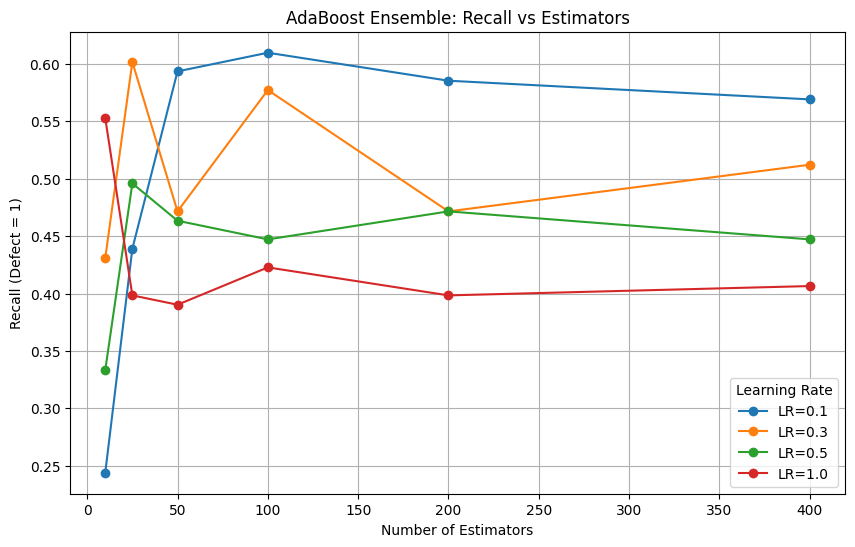

In [24]:
learning_rates = [0.1, 0.3, 0.5, 1.0]
n_estimators_list = [10, 25, 50, 100, 200, 400]

results = []   # To store best model info

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    recalls = []

    for n_est in n_estimators_list:
        probas_all_models = []

        # Train one model per chunk
        for i, chunk in enumerate(majority_chunks):
            balanced_df = pd.concat([chunk, minority_df], axis=0)
            balanced_df = balanced_df.sample(frac=1, random_state=rng_seed+i).reset_index(drop=True)

            Xb = balanced_df.drop(columns=["Defect"])
            yb = balanced_df["Defect"]

            ada = AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=1),
                n_estimators=n_est,
                learning_rate=lr,
                random_state=rng_seed
            )

            ada.fit(Xb, yb)
            probas_all_models.append(ada.predict_proba(X_test)[:, 1])

        # Average probabilities across model ensemble
        avg_probas = np.mean(probas_all_models, axis=0)
        y_pred = (avg_probas >= 0.5).astype(int)

        recall = recall_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)

        recalls.append(recall)
        results.append((lr, n_est, recall, f2))

        print(f"LR={lr}, n={n_est} | Recall={recall:.4f}, F2={f2:.4f}")

    # Plot recall curve
    plt.plot(n_estimators_list, recalls, marker="o", label=f"LR={lr}")

plt.xlabel("Number of Estimators")
plt.ylabel("Recall (Defect = 1)")
plt.title("AdaBoost Ensemble: Recall vs Estimators")
plt.grid(True)
plt.legend(title="Learning Rate")
plt.show()


## 6. Best Model Selection and Confusion Matrix
We select the model with the highest F2-score (β = 2 strongly emphasizes Recall), 
then compute its confusion matrix to understand the distribution of predictions.

In [25]:
# Pick the model with the highest F2 score
best_lr, best_n, best_recall, best_f2 = max(results, key=lambda x: x[3])

print(f"\nBest model based on F2-score:")
print(f"Learning Rate = {best_lr}")
print(f"Estimators    = {best_n}")
print(f"Recall        = {best_recall:.4f}")
print(f"F2-score      = {best_f2:.4f}")

# Rebuild the best model ensemble
probas_all_models = []
for i, chunk in enumerate(majority_chunks):
    balanced_df = pd.concat([chunk, minority_df], axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=rng_seed+i).reset_index(drop=True)

    Xb = balanced_df.drop(columns=["Defect"])
    yb = balanced_df["Defect"]

    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=best_n,
        learning_rate=best_lr,
        random_state=rng_seed
    )

    ada.fit(Xb, yb)
    probas_all_models.append(ada.predict_proba(X_test)[:, 1])

avg_probas = np.mean(probas_all_models, axis=0)
y_pred_best = (avg_probas >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)


Best model based on F2-score:
Learning Rate = 0.1
Estimators    = 100
Recall        = 0.6098
F2-score      = 0.3521

Confusion Matrix:
[[223 498]
 [ 48  75]]
